1. Podaci su dati u obliku histograma. Rekonstruisati sirove uzorke i objasniti zasto je ovaj korak neophodan. Iscrtati pripadajuce histograme.

<h1 style=color:blue>Treci domaci iz AS, Aleksa Boskovic</h1>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

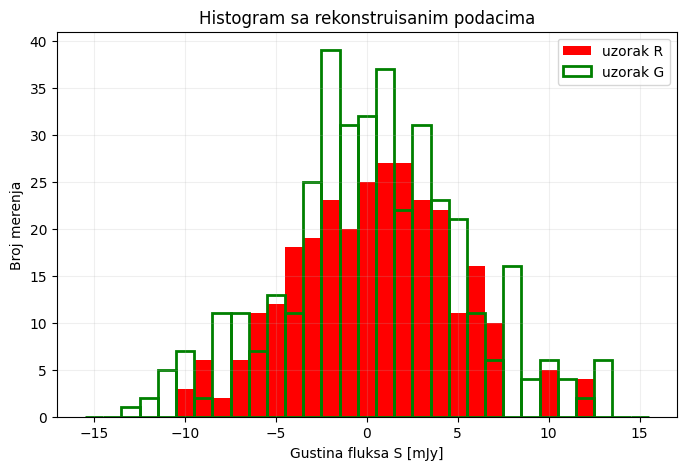

In [23]:
ks_uzorci = np.genfromtxt('gr.dat', skip_header=2, skip_footer=2)
mJy, G, R = ks_uzorci.T

# rekonstrukcija originalnih merenja
uzorak_G = np.repeat(mJy, G.astype(int))
uzorak_R = np.repeat(mJy, R.astype(int))

# grafik sa rekonstruisanim podacima
# moglo je i samo plt.bar sa vec ucitanim podacima iz gr.dat
opseg = (mJy.min() - 0.5, mJy.max() + 0.5)
plt.figure(figsize=(8, 5))
plt.hist(uzorak_R, bins=len(mJy), range=opseg, label='uzorak R', color='red')
plt.hist(uzorak_G, bins=len(mJy), range=opseg, fill=False, label='uzorak G', edgecolor='green', linewidth=2)
plt.xlabel('Gustina fluksa S [mJy]')
plt.ylabel('Broj merenja')
plt.title('Histogram sa rekonstruisanim podacima')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Rekonstrukcija podataka se radi zbog KS testa. Kako KS test ne radi nad frekvencijama sto imamo u gr.dat vec zahteva niz pojedinacnih merenja. Sto znaci da smo samo prosledili originalne nizove iz gr.dat KS test bi to tretirao kao pojedinacna merenja sto je pogresno, zato se radi rekonstrukcija sa np.repeat.

2. Koristeci KS dvouzoracki test, treba ispitati hipotezu 'da postoji eksces gustine fluksa na ne-slucajnim pozicijama'. Dodatno proveriti hiptezu koristeci U test.

In [9]:
# KS test
ks_D, ks_p = ks_2samp(uzorak_G, uzorak_R, alternative='less')
print(f"KS test:")
print(f"D = {ks_D:.3f}")
print(f"p = {ks_p:.3e}")

# U test
u_D, u_p = mannwhitneyu(uzorak_G, uzorak_R, alternative='greater')
print(f"\nU test:")
print(f"D = {u_D:.3f}")
print(f"p = {u_p:.3e}")

KS test:
D = 0.067
p = 2.099e-01

U test:
D = 56613.500
p = 3.988e-01


Nulta hipoteza pretpostavlja da nema razlike u grupi G i R. Kako je KS testi i U test dali p vrednost od 0.2099 i 0.3988 nema statistickih osnova za odbacivanje nulte hipoteze. Samim tim hipoteza koju smo pitali, da li postoji eksces fluksa, otpada.

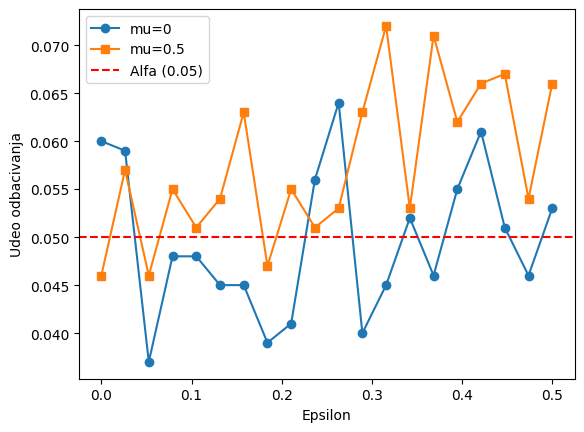

In [ ]:
np.random.seed(42) # normirati seed za proveru

epsiloni = np.linspace(0, 0.5, 20)
niz_mu0 = []
niz_mu05 = []

for eps in epsiloni:
    brojac_mu0 = 0 # brojac odbacenih
    brojac_mu05 = 0 # brojac odbacenih za mu 0.5

    for _ in range(1000):
        # odmah oba scenraija
        uzorak1_mu0 = np.random.normal(0, 1, 10)
        uzorak1_mu05 = np.random.normal(0.5, 1, 10)

        # maske
        uslov1 = np.random.rand(10) < eps
        uslov2 = np.random.rand(10) < eps

        uzorak2_mu0 = np.where(
            uslov1,
            np.random.normal(0, np.sqrt(3), 10),
            np.random.normal(0, 1, 10),
        )

        uzorak2_mu05 = np.where(
            uslov2,
            np.random.normal(0, np.sqrt(3), 10),
            np.random.normal(0.5, 1, 10),
        )
    
        # t test, cita se drugi clan niza sto je p vrednost
        if ttest_ind(uzorak1_mu0, uzorak2_mu0)[1] < 0.05:
            brojac_mu0 += 1

        if ttest_ind(uzorak1_mu05, uzorak2_mu05)[1] < 0.05:
            brojac_mu05 += 1

    niz_mu0.append(brojac_mu0 / 1000)
    niz_mu05.append(brojac_mu05 / 1000)


plt.plot(epsiloni, niz_mu0, label='mu=0', marker='o')
plt.plot(epsiloni, niz_mu05, label='mu=0.5', marker='s')
plt.axhline(0.05, color='red', linestyle='--', label='Alfa (0.05)')
plt.xlabel('Epsilon')
plt.ylabel('Udeo odbacivanja')
plt.legend()
plt.show()